# Region Cutting

In [1]:
import pyearthtools.data

import warnings

with warnings.catch_warnings(action="ignore"):
    import site_archive_nci

## Variables

In [2]:
doi = '2022-01-01T01'
var = 'tcwv'
plot_kwargs = {'figsize': (20,10)}

### Problem Space
The global dataset's commonly worked with are quite large, and thus it is useful to cut them to regions of interest

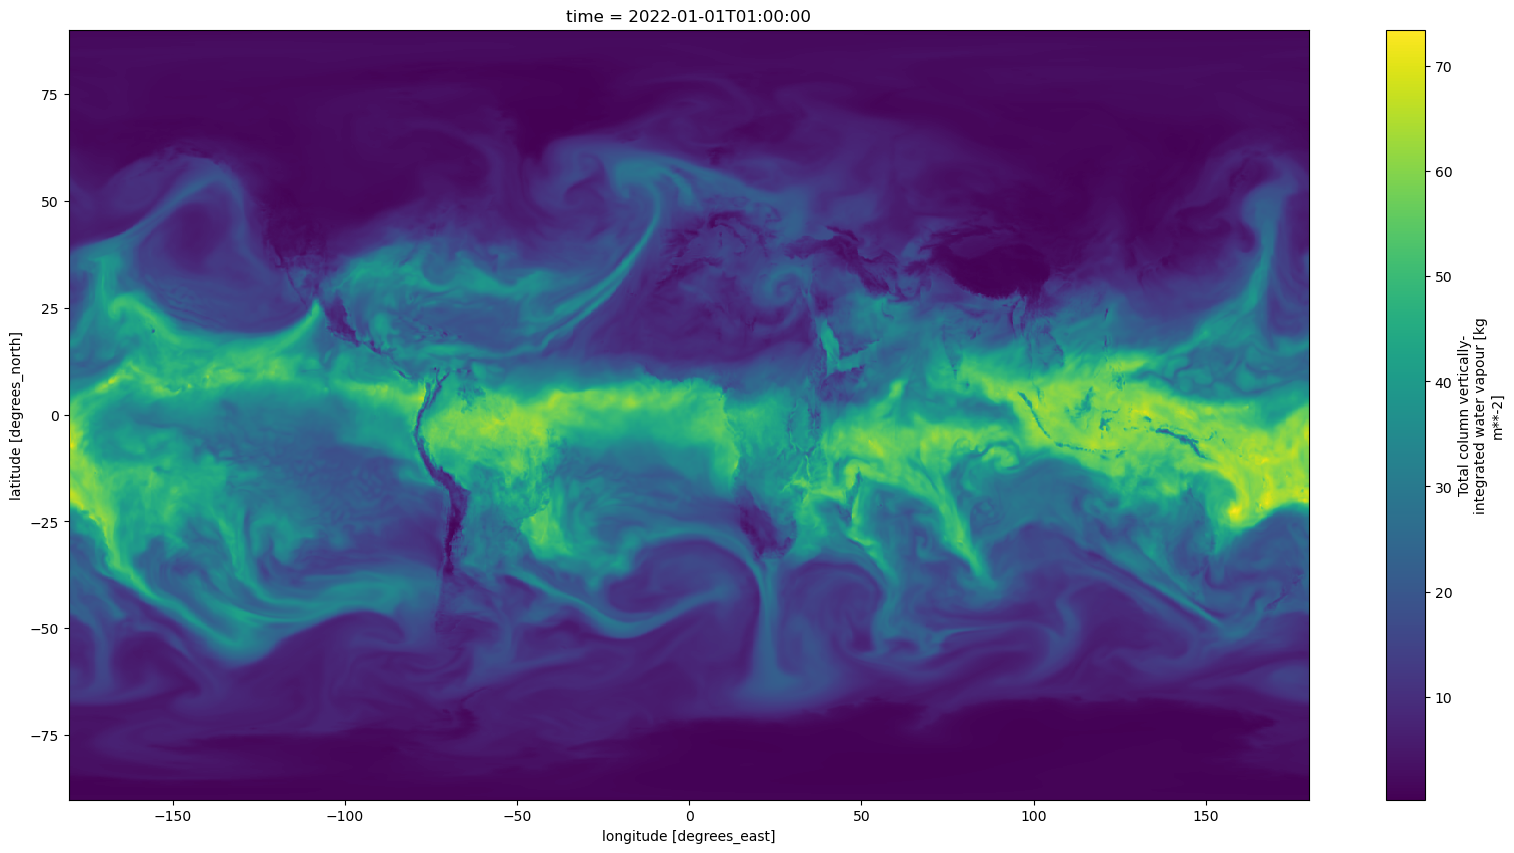

In [3]:
era5 = pyearthtools.data.archive.ERA5(var)
era5(doi)[var].plot(**plot_kwargs)

## Region Transform
`pyearthtools.data.transform` provides a region transform to apply common region cutting when retrieving data.

By using this transform, when retrieving multiple timesteps through series, or other indexing, the data will be culled at the earliest opportunity to limit unneccessary operations.

The `region` transform provides a few options, 
 - Bounding Box
 - Reference Dataset
 - Common String Lookup
 - Shapefile
 - Static Shapefile retrieval 

### Examples

#### Bounding Box

In [4]:
# Approximate Australian region
bounding_box = pyearthtools.data.transform.region.Bounding(-50, -10, 110, 155)  
bounding_box

Bounding
	Initialisation                 Cut with Bounding box
		 max_lat                        -10
		 max_lon                        155
		 min_lat                        -50
		 min_lon                        110

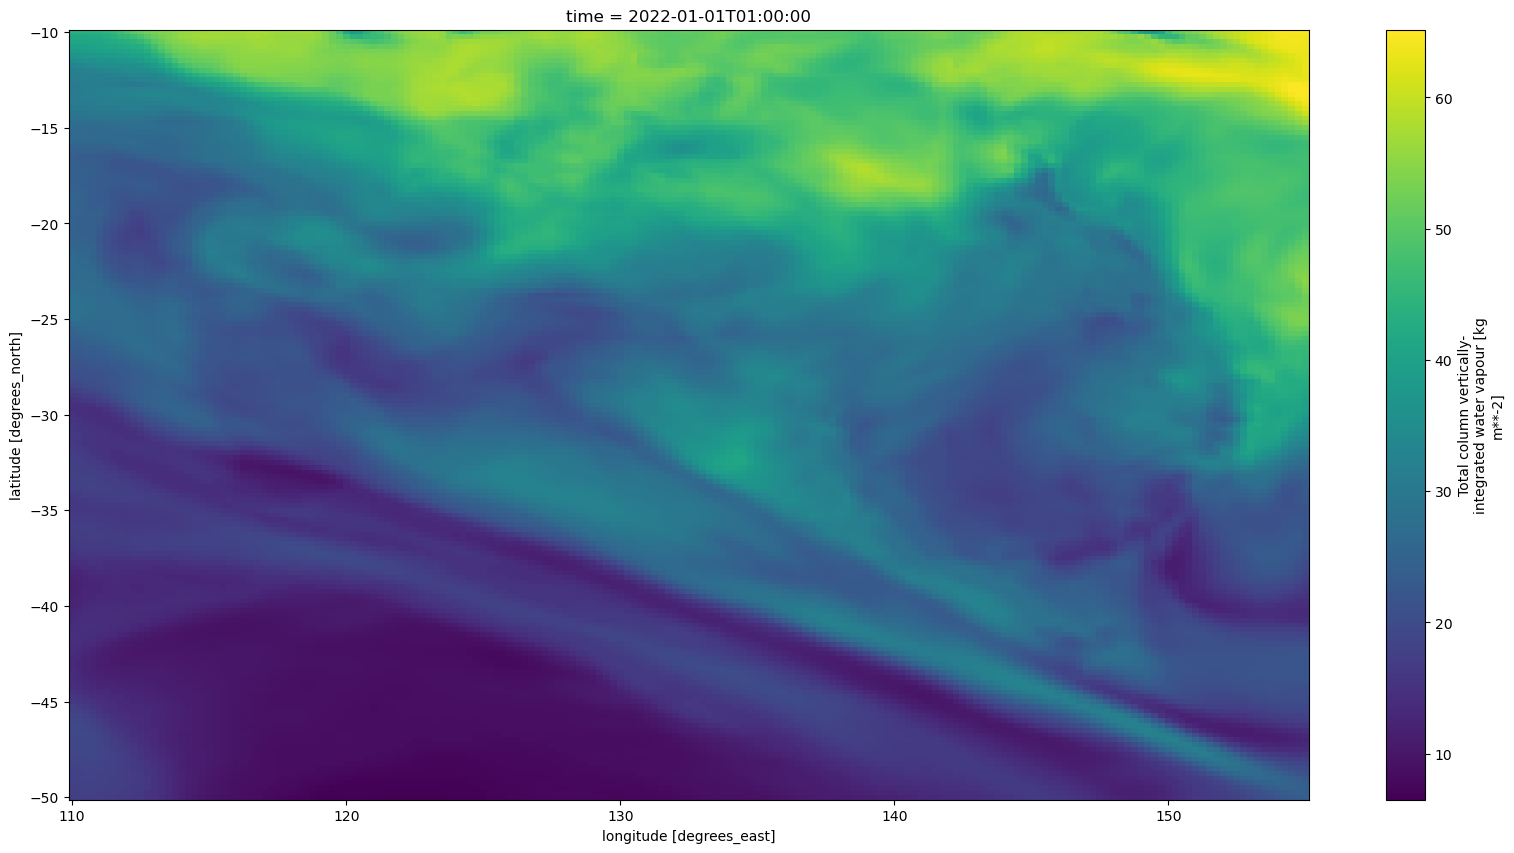

In [5]:
era5(doi, transforms = bounding_box)[var].plot(**plot_kwargs)

#### Matching Dataset Regions

It is not uncommon for dataset regions not to match. In this case, it is often useful to be able to easily get one dataset with respect to the boundaries of another, smaller dataset. Or, for that matter, the largest intersection of multiple datasets.

In this example, we use the "like" functionality to subset ERA5 to a bounding box based on the extent of the Himawari satellite observations, without having to go through the exercise of determining that bounding box numerically. The result is similar to the plot above, but not quite the same.

In [6]:
like_dataset = pyearthtools.data.transform.region.like(pyearthtools.data.archive.Himawari('cloud_type')(doi))
like_dataset

Bounding
	Initialisation                 Cut with Bounding box
		 max_lat                        -10.0
		 max_lon                        156.25999450683594
		 min_lat                        -44.5
		 min_lon                        112.0

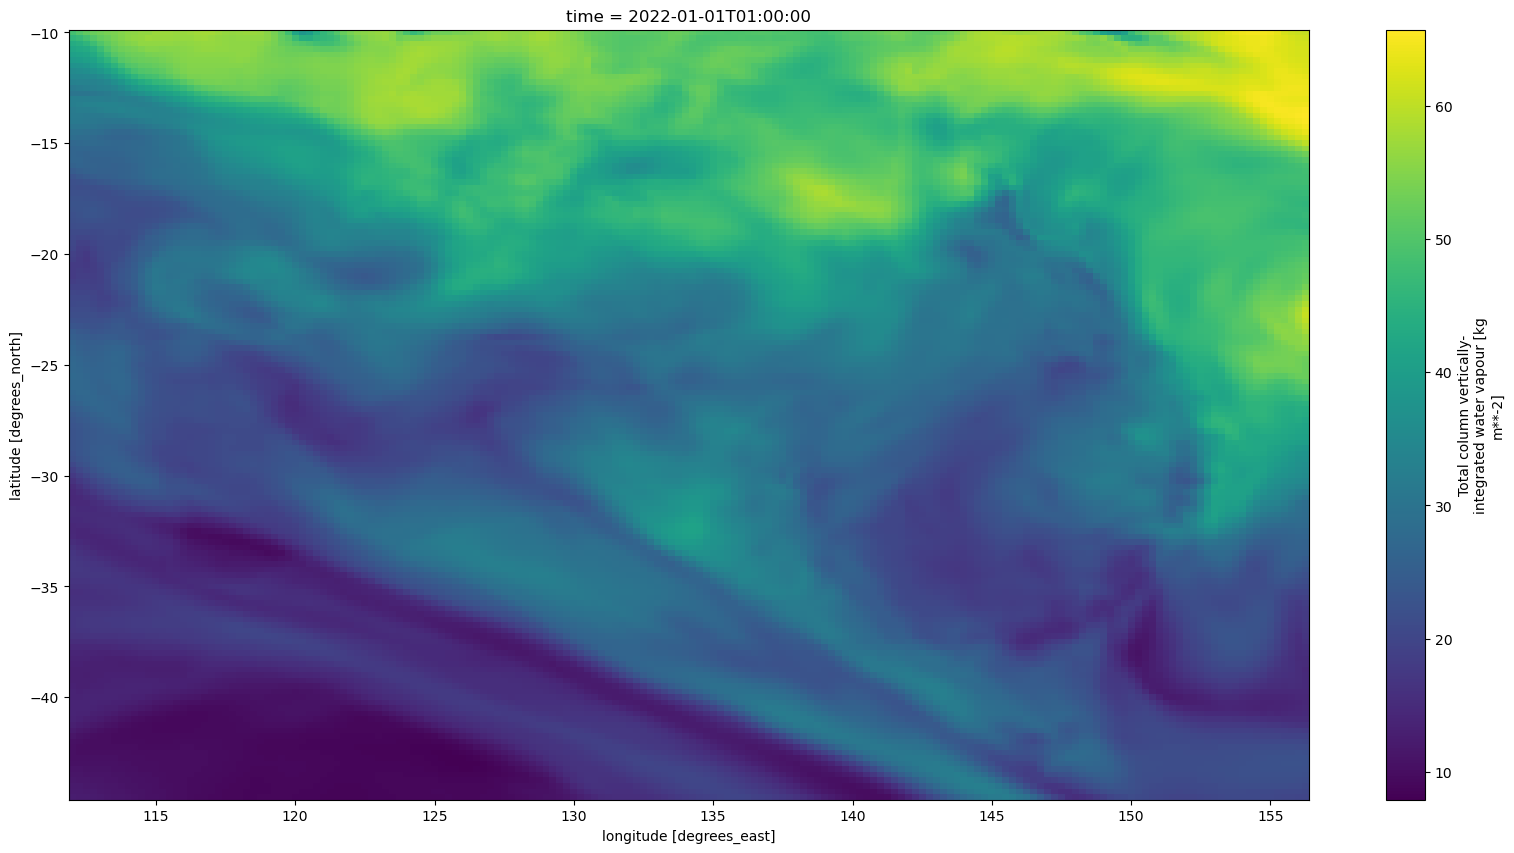

In [7]:
era5(doi, transforms = like_dataset)[var].plot(**plot_kwargs)

#### Lookup
Cut ERA5 to the predefined Australia Region

In [8]:
lookup = pyearthtools.data.transform.region.lookup('Australia')
lookup

Bounding
	Initialisation                 Cut with Bounding box
		 max_lat                        -5
		 max_lon                        155
		 min_lat                        -50
		 min_lon                        110

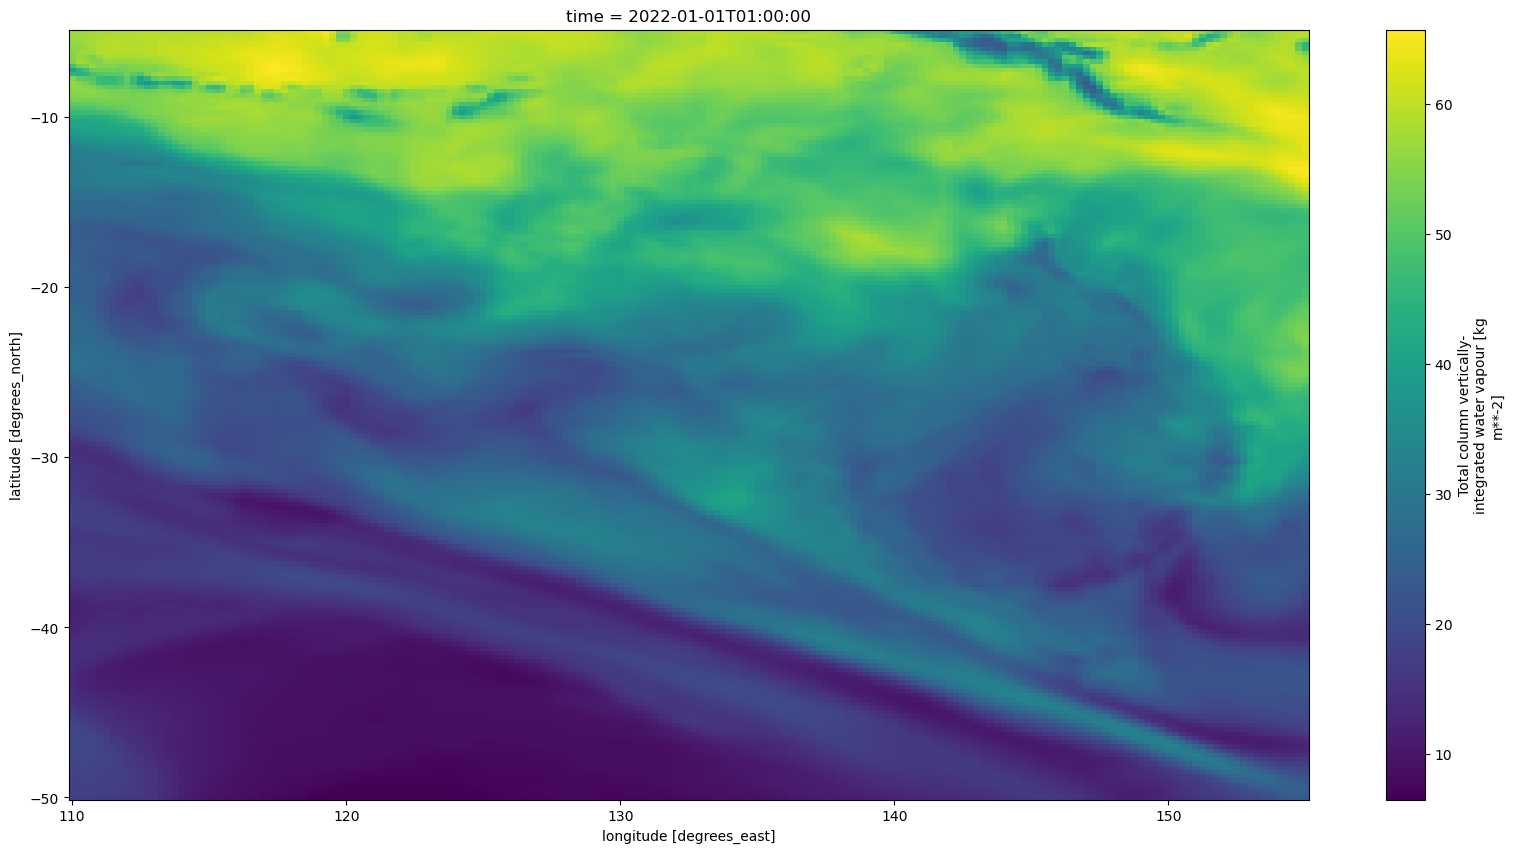

In [9]:
era5(doi, transforms = lookup)[var].plot(**plot_kwargs)

#### from_geosearch
Using a shapefile cut to the Australian Region

In [10]:
shapefile_trim = pyearthtools.data.transform.region.from_geosearch('Australia')
shapefile_trim

ShapeFile
	Initialisation                 
		 crs                            None
		 shapefile                      0    MULTIPOLYGON (((96.91524 -12.15313, 96.91523 -...
Name: geometry, dtype: geometry

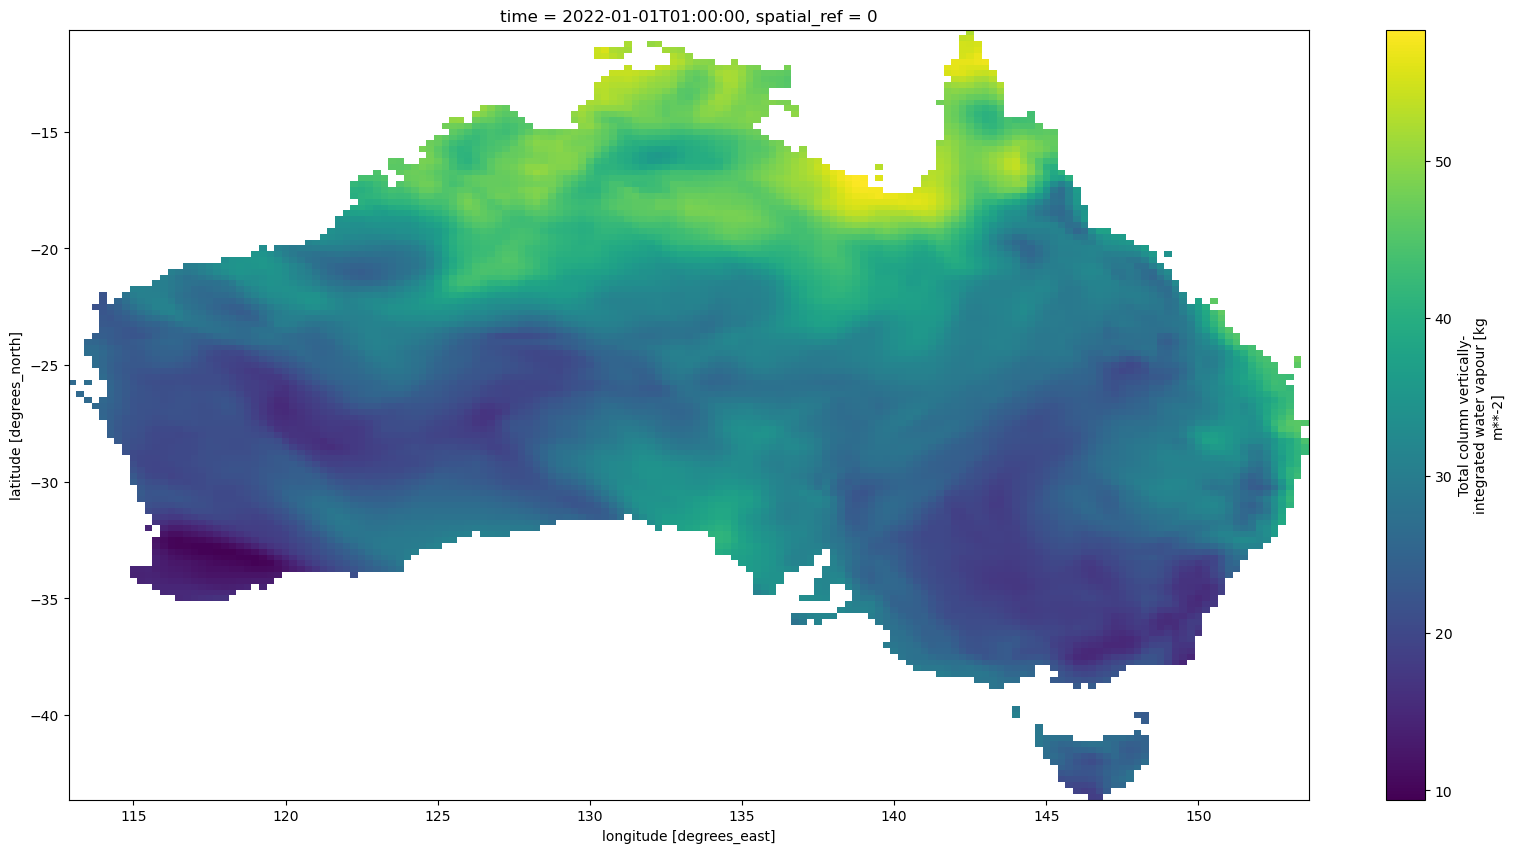

In [11]:
era5(doi, transforms = shapefile_trim)[var].plot(**plot_kwargs)

It is also possible to use the `pyearthtools.data.static.geographic` sources to search for shapefiles.

In [12]:
pyearthtools.data.static.geographic()('World').head()

,iso3,status,color_code,name,continent,region,iso_3166_1_,french_shor,geometry
0,UGA,Member State,UGA,Uganda,Africa,Eastern Africa,UG,Ouganda,"POLYGON ((33.9211 -1.00194, 33.92027 -1.00111,..."
1,UZB,Member State,UZB,Uzbekistan,Asia,Central Asia,UZ,Ouzbékistan,"POLYGON ((70.97081 42.25467, 70.98054 42.26205..."
2,IRL,Member State,IRL,Ireland,Europe,Northern Europe,IE,Irlande,"MULTIPOLYGON (((-9.97014 54.02083, -9.93833 53..."
3,ERI,Member State,ERI,Eritrea,Africa,Eastern Africa,ER,Érythrée,"MULTIPOLYGON (((40.13583 15.7525, 40.12861 15...."
4,None,Adm. by EGY,EGY,Ma'tan al-Sarra,Africa,Northern Africa,None,Ma'tan al-Sarra,"POLYGON ((33.25104 21.99977, 34.15064 21.99603..."


In [13]:
shapefile_trim = pyearthtools.data.transform.region.from_geosearch('World', column = 'continent', value = 'Americas')
shapefile_trim

ShapeFile
	Initialisation                 
		 crs                            None
		 shapefile                      11     POLYGON ((-69.87486 12.41528, -69.88224 12.411...
14     POLYGON ((-77.68861 18.48639, -77.64002 18.479...
17     MULTIPOLYGON (((-87.81903 17.42902, -87.83153 ...
26     POLYGON ((-51.68407 4.03416, -51.70417 4.02611...
34     MULTIPOLYGON (((-66.87528 44.61944, -66.88612 ...
36     MULTIPOLYGON (((-43.64806 59.84749, -43.84972 ...
39     POLYGON ((-89.14195 17.81889, -89.14223 17.719...
41     POLYGON ((-54.16668 5.3474, -54.1707 5.34222, ...
49     MULTIPOLYGON (((-155.00558 19.32888, -155.1453...
50     POLYGON ((-61.7175 12.00389, -61.74973 11.9969...
51     POLYGON ((-81.0957 19.31264, -81.10556 19.3027...
52     MULTIPOLYGON (((-68.57445 18.12945, -68.56855 ...
62     POLYGON ((-69.95692 -4.23687, -69.95029 -4.262...
64     POLYGON ((-54.59892 -25.57322, -54.62334 -25.6...
71     MULTIPOLYGON (((-64.66084 18.38389, -64.66724 ...
84     MULTIPOLYGON (((-83.13185 14.99298, -83.15889 ...
90     POLYGON ((-62.16556 16.67166, -62.17139 16.671...
93     POLYGON ((-83.13185 14.99298, -83.19667 14.956...
97     POLYGON ((-64.80334 32.2625, -64.82306 32.2605...
105    POLYGON ((-59.51028 13.055, -59.53306 13.05056...
106    MULTIPOLYGON (((-65.44139 18.09028, -65.52501 ...
117    MULTIPOLYGON (((-78.11932 2.50208, -78.12556 2...
122    POLYGON ((-57.2485 5.48611, -57.2716 5.38486, ...
128    MULTIPOLYGON (((-61.18507 8.49674, -61.19417 8...
132    POLYGON ((-61.28028 15.2375, -61.36362 15.1980...
134    MULTIPOLYGON (((-64.76418 17.77861, -64.75598 ...
143    MULTIPOLYGON (((-75.22373 19.90155, -75.22696 ...
144    POLYGON ((-83.6458 10.92485, -83.63747 10.9202...
154    POLYGON ((-53.3743 -33.74067, -53.39917 -33.75...
156    MULTIPOLYGON (((-81.67847 7.38861, -81.64944 7...
157    MULTIPOLYGON (((-68.19736 12.22264, -68.19292 ...
162    MULTIPOLYGON (((-60.92306 10.79722, -60.94445 ...
168    MULTIPOLYGON (((-68.64312 -54.88861, -68.63723...
170    MULTIPOLYGON (((-73.03584 21.14167, -73.12361 ...
171    MULTIPOLYGON (((-67.20889 -55.89104, -67.24695...
174    POLYGON ((-62.70167 17.33694, -62.62251 17.241...
177    POLYGON ((-60.90028 13.77833, -60.93834 13.717...
181    POLYGON ((-89.34831 14.43198, -89.33216 14.410...
190    MULTIPOLYGON (((-61.68459 17.02597, -61.73806 ...
196    POLYGON ((-63.15375 18.16528, -63.16778 18.164...
199    POLYGON ((-160.02114 -0.39806, -160.02811 -0.3...
204    MULTIPOLYGON (((-71.12757 21.44263, -71.14605 ...
205    POLYGON ((-58.15889 -20.16806, -58.13722 -20.1...
206    MULTIPOLYGON (((-82.5446 21.57389, -82.59862 2...
209    POLYGON ((-60.81695 14.47333, -60.82056 14.455...
214    POLYGON ((-177.38806 28.18638, -177.39334 28.1...
218    MULTIPOLYGON (((-61.24556 15.87167, -61.25667 ...
222    MULTIPOLYGON (((-48.55056 -27.82139, -48.55667...
223    MULTIPOLYGON (((-72.81557 18.69889, -72.82584 ...
226    MULTIPOLYGON (((-61.03076 -51.8659, -61.01639 ...
236    POLYGON ((-61.16979 13.13444, -61.18445 13.130...
241    MULTIPOLYGON (((-91.82862 18.63916, -91.83446 ...
244    MULTIPOLYGON (((-80.19335 -3.03472, -80.2114 -...
Name: geometry, dtype: geometry

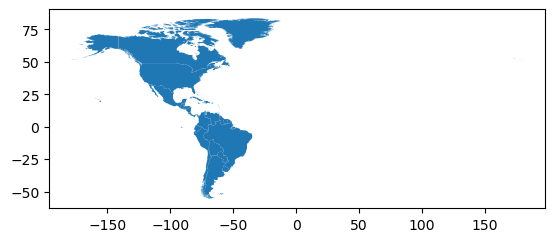

In [14]:
shapefile_trim.plot()

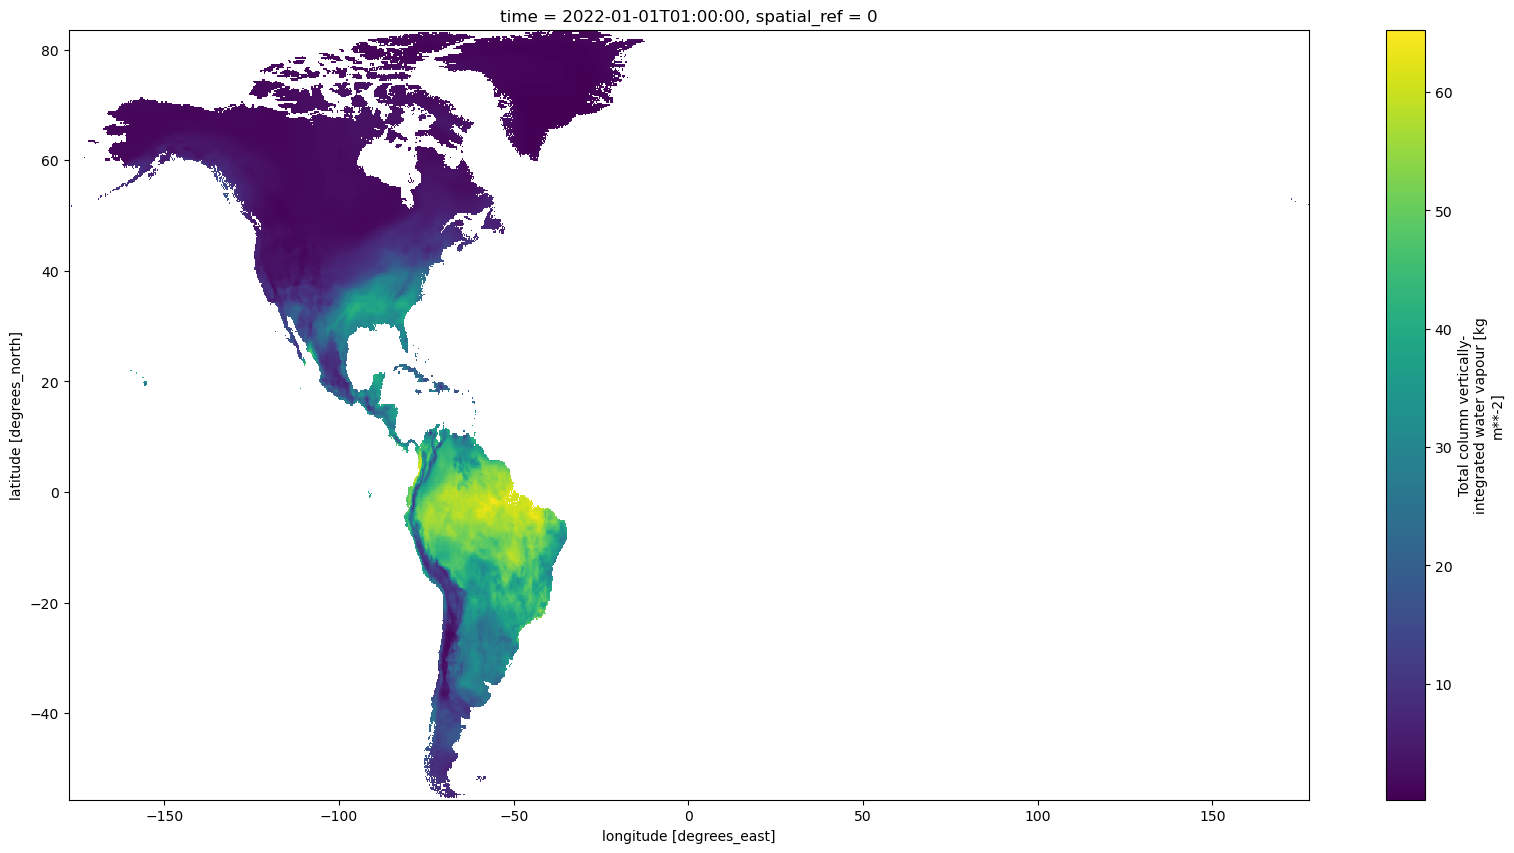

In [15]:
era5(doi, transforms = shapefile_trim)[var].plot(**plot_kwargs)

#### from_shapefile

<Axes: >

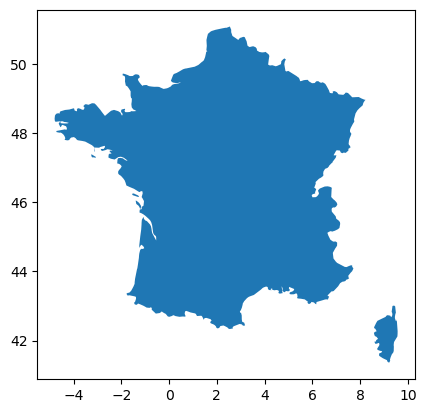

In [16]:
shapefile = pyearthtools.data.static.geographic()('World')
shapefile = shapefile[shapefile.name == 'France']
shapefile.plot()

In [17]:
shapefile_trim = pyearthtools.data.transform.region.from_shapefile(shapefile.geometry)
shapefile_trim

ShapeFile
	Initialisation                 
		 crs                            None
		 shapefile                      152    MULTIPOLYGON (((9.4475 42.68305, 9.45014 42.63...
Name: geometry, dtype: geometry

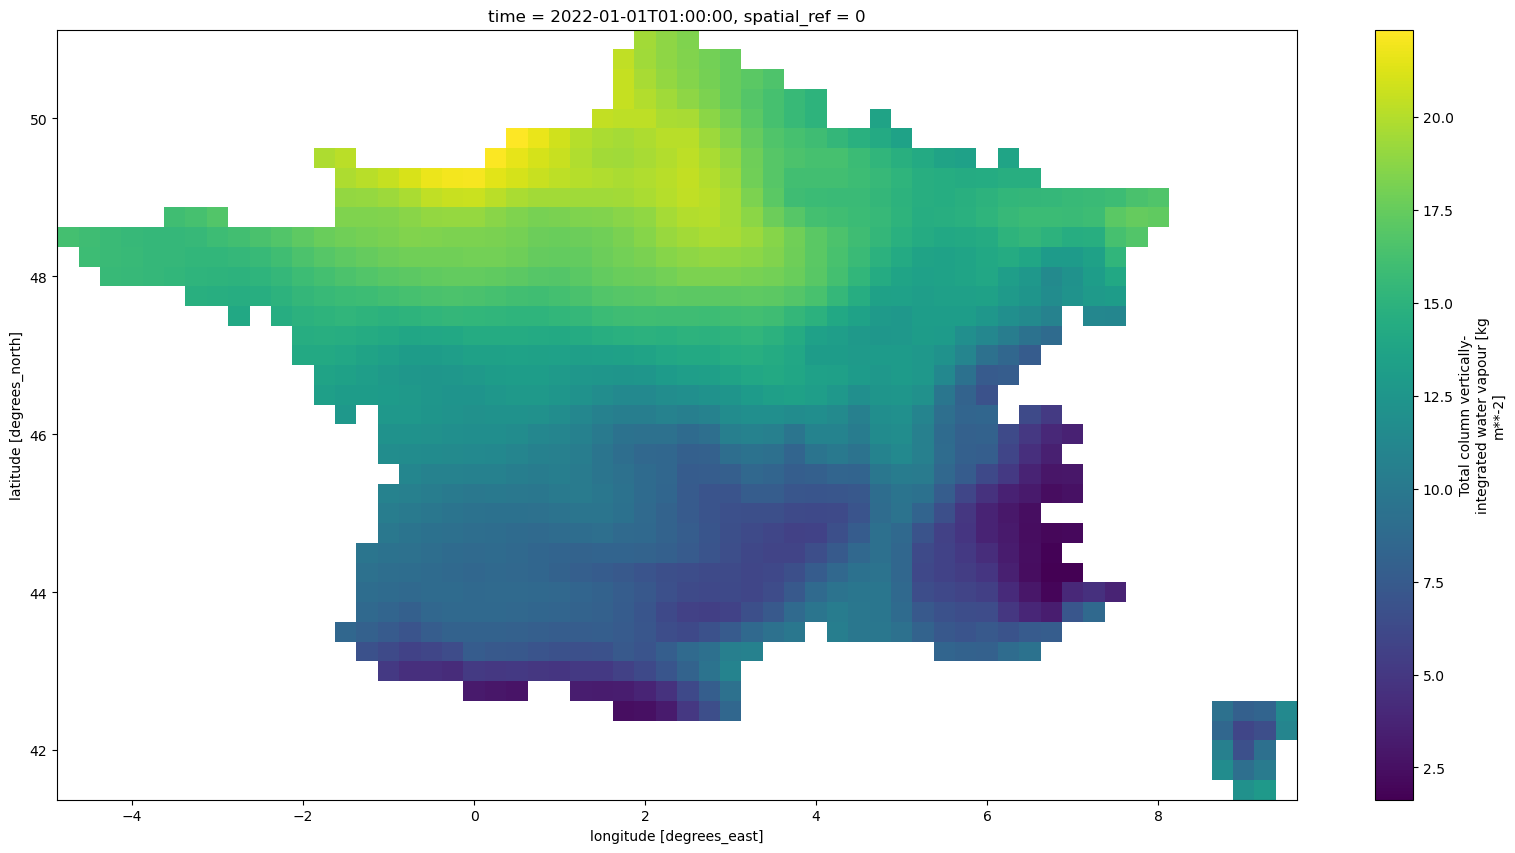

In [18]:
era5(doi, transforms = shapefile_trim)[var].plot(**plot_kwargs)